In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

from architecture.config import load_config, path

In [2]:
config = load_config("configs/default.yaml")
log_dir = path(config, "log")

if not log_dir.exists():
    raise FileNotFoundError (log_dir, "Does not exist yet, please train the model first.")

df = pd.read_csv((log_dir / "log.csv")).dropna()

checkpoint_epochs = range(10, df["epoch"].iloc[-1] + 1, 10)
image_paths = [(log_dir / f"epoch_{epoch}.png") for epoch in checkpoint_epochs]

for path in image_paths:
    if not path.exists():
        raise FileNotFoundError (path, "Does not exist.")

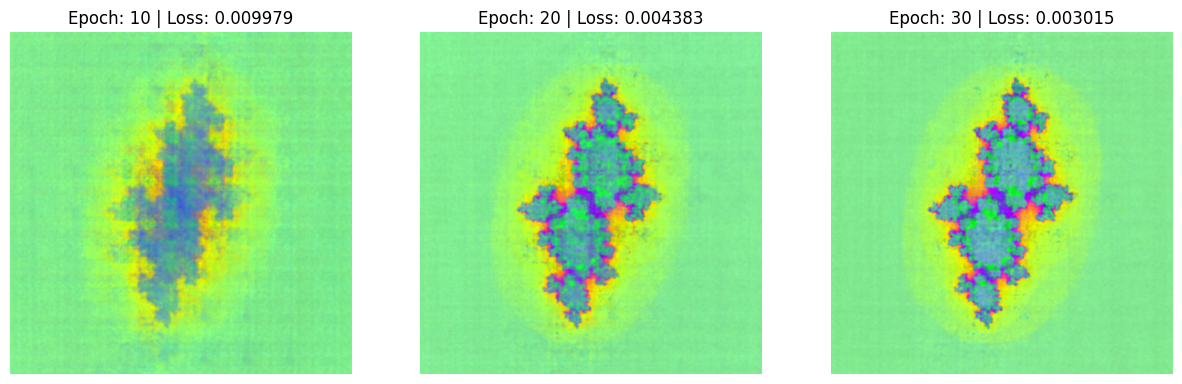

In [3]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(len(image_paths) * 5, 6))

for ax, epoch, image_path in zip(axes, checkpoint_epochs, image_paths):
    loss = df.loc[df["epoch"] == epoch, "loss"].iloc[0]
    ax.imshow(Image.open(image_path))
    ax.axis("off")
    ax.set_title(f"Epoch: {epoch} | Loss: {loss:.6f}")